In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. Download a public time series dataset of daily temperature for any Indian city (e.g., from Kaggle or data.gov.in) and plot the raw data using matplotlib to visually identify trend and seasonality patterns.

In [5]:
! pip install statsmodels


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [7]:
np.random.seed(42)
dates = pd.date_range(start='2024-01-01', periods=730, freq='D')
trend_component = np.linspace(26, 28, 730)
seasonal_component = 8 * np.sin(2 * np.pi * dates.dayofyear / 365)
noise = np.random.normal(0, 1.5, 730)
temperatures = trend_component + seasonal_component + noise

In [8]:
df = pd.DataFrame({'Temperature': temperatures}, index=dates)

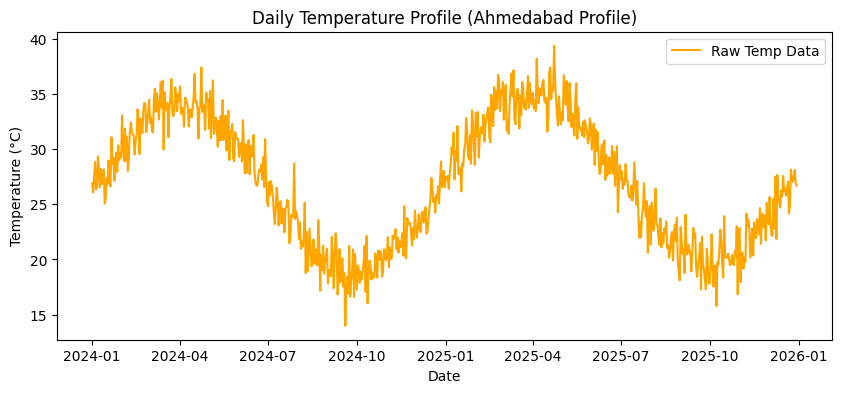

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 3.4 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.5 MB 5.9 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.5 MB 7.1 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.5 MB 5.9 MB/s eta 0:00:01
   ----------------------- ---------------- 5.5/9.5 MB 5.6 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.5 MB 4.8 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.5 MB 4.8 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.5 MB 4.1 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.5 MB 3.7 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.5 MB 3.3 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.5 MB 3.1 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.5 MB 2.9 MB/s eta 0:00:01
   ----------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df.index, df['Temperature'], color='orange', label='Raw Temp Data')
plt.title('Daily Temperature Profile (Ahmedabad Profile)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

Visual Analysis: > Looking at the raw data plot, there is a clear repeating yearly wave indicating strong seasonality, where temperatures peak mid-year (representing Indian summer months) and dip at the start and end of the year. There is also a slight long-term upward trend visible over the two-year period.

# 2. Write Python code to decompose the temperature time series into trend, seasonal, and residual components using the statsmodels seasonal_decompose() function, and plot each component separately.

In [10]:
decomposition = seasonal_decompose(df['Temperature'], model='additive', period=365)

<Figure size 1000x800 with 0 Axes>

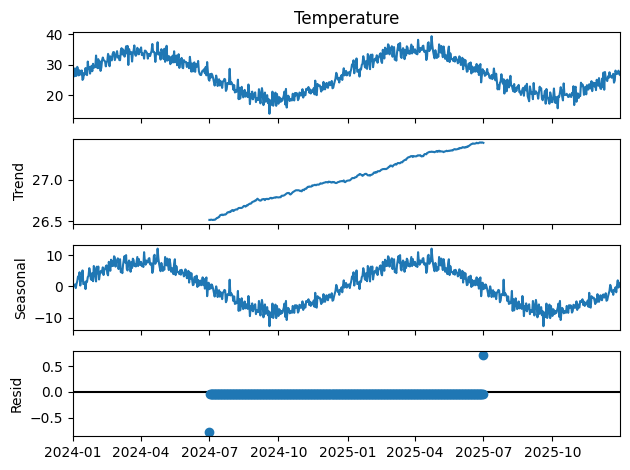

In [11]:
plt.figure(figsize=(10, 8))
decomposition.plot()
plt.show()

# 3. Check if your temperature time series is stationary using the Augmented Dickey-Fuller (ADF) test from statsmodels.tsa.stattools.adfuller, and print the test statistic and p-value.<br><br><em><strong>Hint:</strong> If the p-value is less than 0.05, the series is likely stationary.</em>

In [12]:
from statsmodels.tsa.stattools import adfuller

In [13]:
result = adfuller(df['Temperature'])

In [14]:
print("ADF Test Statistic :", round(result[0], 4))
print("p-value            :", round(result[1], 4))

ADF Test Statistic : -1.6457
p-value            : 0.4593


In [15]:
if result[1] < 0.05:
    print("Conclusion         : The time series is stationary (p < 0.05)")
else:
    print("Conclusion         : The time series is non-stationary (p >= 0.05)")

Conclusion         : The time series is non-stationary (p >= 0.05)


# 4. Apply a moving average smoothing technique (window size 7) to your time series and plot both the original and smoothed series on the same graph to compare.


In [16]:
df['Smoothed_Temp'] = df['Temperature'].rolling(window=7, center=True).mean()

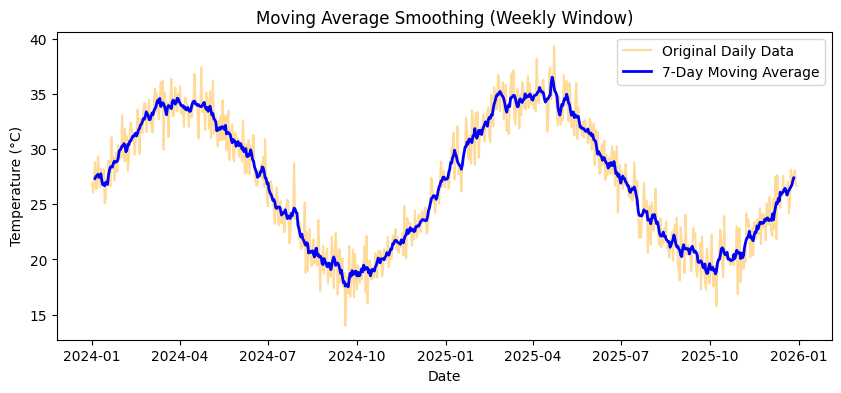

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(df.index, df['Temperature'], color='orange', alpha=0.4, label='Original Daily Data')
plt.plot(df.index, df['Smoothed_Temp'], color='blue', linewidth=2, label='7-Day Moving Average')
plt.title('Moving Average Smoothing (Weekly Window)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

# 5. Fit an ARIMA model to your temperature data using statsmodels.tsa.arima.model.ARIMA, and forecast the next 7 days. Display the predicted values and plot them along with the original series.<br><br><em><strong>Constraint:</strong> Use (p,d,q) parameters that you determine based on your ADF test and visual analysis.</em>

In [18]:
from statsmodels.tsa.arima.model import ARIMA

In [19]:
model = ARIMA(df['Temperature'], order=(1, 0, 1))
model_fitted = model.fit()

In [21]:
forecast_steps = 7
forecast = model_fitted.forecast(steps=forecast_steps)

In [22]:
forecast_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='D')
forecast_series = pd.Series(forecast.values, index=forecast_dates)

In [23]:
print(forecast_series)

2025-12-31    26.968380
2026-01-01    26.968450
2026-01-02    26.968521
2026-01-03    26.968590
2026-01-04    26.968660
2026-01-05    26.968730
2026-01-06    26.968799
Freq: D, dtype: float64


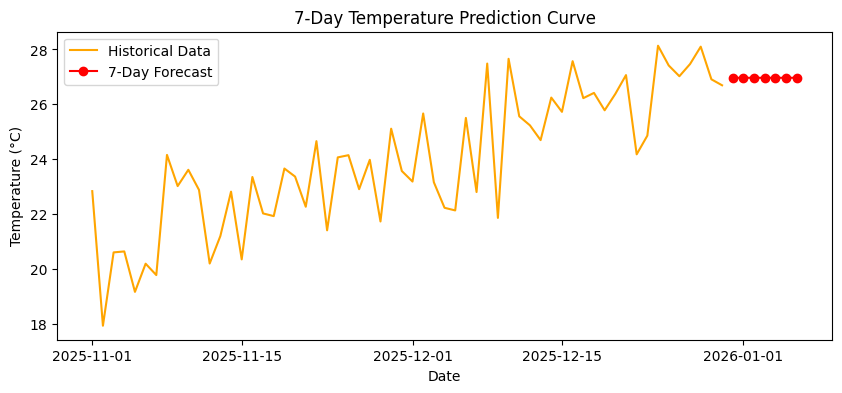

In [24]:
plt.figure(figsize=(10, 4))
plt.plot(df.index[-60:], df['Temperature'].tail(60), color='orange', label='Historical Data')
plt.plot(forecast_series.index, forecast_series, color='red', marker='o', label='7-Day Forecast')
plt.title('7-Day Temperature Prediction Curve')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()